## Exámen 1 - Práctico
### Objetivo general

La parte practica busca evaluar si el estudiante entiende el flujo completo de modelado visto en clase:

- revision inicial de datos
- analisis exploratorio
- analisis bivariado
- regresion lineal simple
- regresion lineal multiple
- regresion polinomial
- Ridge regression
- StandardScaler
- KNN
- cross validation
- comparacion de modelos usando R2

El objetivo no es solo obtener el mejor R2. El objetivo es que el estudiante explique que hizo, por que lo hizo, que encontro y que significa cada resultado.

## Regla obligatoria para ambos datasets

En cada seccion debe haber una conclusion escrita.

No basta con correr codigo, imprimir tablas o mostrar graficas. Despues de cada analisis o modelo, el estudiante debe explicar con sus palabras:

- que hizo
- que resultado obtuvo
- que significa ese resultado
- si el modelo o variable parece servir
- que decision tomaria con base en el resultado

Si una seccion no tiene interpretacion o conclusion, esta incompleta aunque el codigo funcione.

Dependiendo el que te toque (hitters o boston) 

la idea es que apliques todo lo que vimos en clase, hagas varioa modelos y des conclusiones

 

## 1. Revisión inicial de los datos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import linear_model
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error

In [2]:
df = pd.read_csv('../Data/Hitters_examen.csv')

In [3]:
df.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


In [4]:
df.shape

(322, 20)

In [5]:
df.dtypes

AtBat          int64
Hits           int64
HmRun          int64
Runs           int64
RBI            int64
Walks          int64
Years          int64
CAtBat         int64
CHits          int64
CHmRun         int64
CRuns          int64
CRBI           int64
CWalks         int64
League        object
Division      object
PutOuts        int64
Assists        int64
Errors         int64
Salary       float64
NewLeague     object
dtype: object

In [6]:
df.isna().sum()

AtBat         0
Hits          0
HmRun         0
Runs          0
RBI           0
Walks         0
Years         0
CAtBat        0
CHits         0
CHmRun        0
CRuns         0
CRBI          0
CWalks        0
League        0
Division      0
PutOuts       0
Assists       0
Errors        0
Salary       59
NewLeague     0
dtype: int64

In [7]:
df = df.dropna()

In [8]:
df.isna().sum()

AtBat        0
Hits         0
HmRun        0
Runs         0
RBI          0
Walks        0
Years        0
CAtBat       0
CHits        0
CHmRun       0
CRuns        0
CRBI         0
CWalks       0
League       0
Division     0
PutOuts      0
Assists      0
Errors       0
Salary       0
NewLeague    0
dtype: int64

### Conclusión de la revisión inicial



Primero revise el dataset y tenia 322 observaciones con 20 variables
vi que Salary tenia 59 valores faltantes y como es la variable que quiero predecir elimine esas filas
despues de eso quedaron 263 observaciones
tambien hay variables numericas y 3 categoricas que son League Division y NewLeague entonces mas adelante tengo que tomarlas en cuenta dependiendo del modelo

## 2. Análisis exploratorio

In [9]:
df[['Salary']].describe().round(2)

,Salary
count,263.00
mean,535.93
std,451.12
min,67.50
25%,190.00
50%,425.00
75%,750.00
max,2460.00


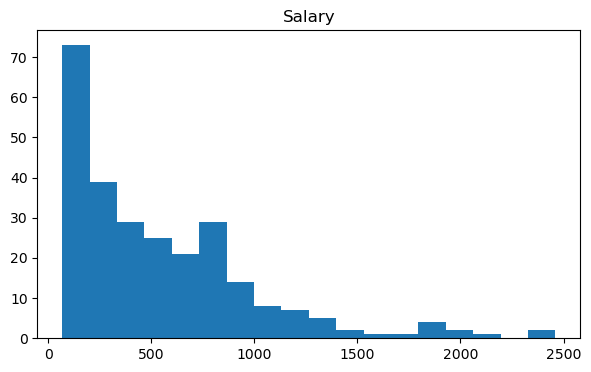

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(df['Salary'], bins=18)
ax.set_title('Salary')

plt.show()

### Conclusión del análisis exploratorio

Revise Salary y vi que tiene un promedio de 535.93 y una mediana de 425
tambien tiene bastante variacion ya que va desde 67.5 hasta 2460
en el histograma se ve que hay mas jugadores con salarios bajos y pocos con salarios muy altos
entonces hay algunos valores altos que hacen que el promedio aumente

## 3. Análisis bivariado

In [11]:
df_bivariado = df.copy()

del df_bivariado['League']
del df_bivariado['Division']
del df_bivariado['NewLeague']

df_bivariado.corr()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary
AtBat,1.000000,0.963969,0.555102,0.899829,0.796015,0.624448,0.012725,0.207166,0.225341,0.212422,0.237278,0.221393,0.132926,0.309607,0.342117,0.325577,0.394771
Hits,0.963969,1.000000,0.530627,0.910630,0.788478,0.587311,0.018598,0.206678,0.235606,0.189364,0.238896,0.219384,0.122971,0.299688,0.303975,0.279876,0.438675
HmRun,0.555102,0.530627,1.000000,0.631076,0.849107,0.440454,0.113488,0.217464,0.217496,0.492526,0.258347,0.349858,0.227183,0.250931,-0.161602,-0.009743,0.343028
Runs,0.899829,0.910630,0.631076,1.000000,0.778692,0.697015,-0.011975,0.171811,0.191327,0.229701,0.237831,0.202335,0.163700,0.271160,0.179258,0.192609,0.419859
RBI,0.796015,0.788478,0.849107,0.778692,1.000000,0.569505,0.129668,0.278126,0.292137,0.442190,0.307226,0.387777,0.233619,0.312065,0.062902,0.150155,0.449457
Walks,0.624448,0.587311,0.440454,0.697015,0.569505,1.000000,0.134793,0.269450,0.270795,0.349582,0.332977,0.312697,0.429140,0.280855,0.102523,0.081937,0.443867
Years,0.012725,0.018598,0.113488,-0.011975,0.129668,0.134793,1.000000,0.915681,0.897844,0.722371,0.876649,0.863809,0.837524,-0.020019,-0.085118,-0.156512,0.400657
CAtBat,0.207166,0.206678,0.217464,0.171811,0.278126,0.269450,0.915681,1.000000,0.995057,0.801676,0.982747,0.950730,0.906712,0.053393,-0.007897,-0.070478,0.526135
CHits,0.225341,0.235606,0.217496,0.191327,0.292137,0.270795,0.897844,0.995057,1.000000,0.786652,0.984542,0.946797,0.890718,0.067348,-0.013144,-0.068036,0.548910
CHmRun,0.212422,0.189364,0.492526,0.229701,0.442190,0.349582,0.722371,0.801676,0.786652,1.000000,0.825625,0.927903,0.810878,0.093822,-0.188886,-0.165369,0.524931


In [12]:
df_bivariado['CRBI_bin'] = pd.qcut(
    df_bivariado['CRBI'],
    q=10,
    labels=False
) + 1

bivariado_CRBI = df_bivariado.groupby('CRBI_bin').mean()

bivariado_CRBI[['CRBI', 'Salary']]

,CRBI,Salary
CRBI_bin,,
1,25.777778,200.438259
2,56.074074,135.500000
3,95.192308,239.634615
4,133.680000,327.660000
5,193.500000,462.827393
6,279.920000,538.633360
7,346.000000,852.064115
8,430.769231,848.846115
9,643.269231,749.409346


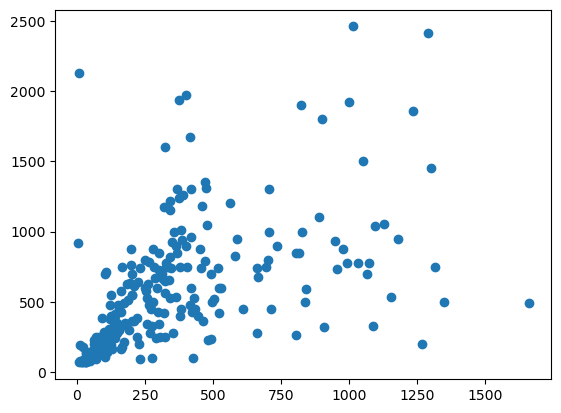

In [13]:
plt.scatter(df.CRBI, df.Salary)
plt.show()

### Conclusión del análisis bivariado



En el analisis bivariado revise la relacion de las variables numericas con Salary
CRBI fue la variable con mayor correlacion con 0.566966 seguida de CRuns con 0.562678 y CHits con 0.548910
entonces CRBI parece ser la variable que mas informacion aporta por si sola y la voy a usar para comenzar con la regresion lineal simple

## 4. Regresión lineal simple

In [14]:
X = df[['CRBI']]
y = df['Salary']

model = LinearRegression().fit(X,y)
predicciones = model.predict(X)

r2_simple = r2_score(y_pred=predicciones, y_true=y)
r2_simple

0.3214500886678947

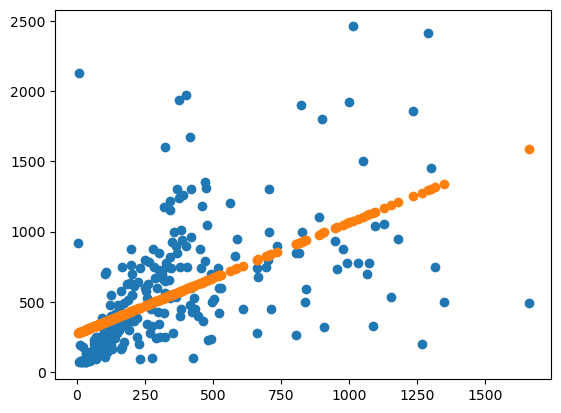

In [15]:
plt.scatter(df.CRBI, df.Salary)
plt.scatter(df.CRBI, predicciones)
plt.show()

### Conclusión de regresión lineal simple



Use CRBI para hacer la regresion lineal simple porque fue la variable que tuvo mayor correlacion con Salary
el modelo dio un R2 de 0.3215 entonces explica aproximadamente el 32.15% de la variacion de Salary
CRBI si aporta informacion pero todavia queda una parte bastante grande que el modelo no explica
por eso ahora probaria una regresion multiple usando mas variables

## 5. Regresión lineal múltiple

In [16]:
df = pd.get_dummies(df)

In [17]:
X = df.copy()
del X['Salary']
y = df['Salary']

model = linear_model.LinearRegression().fit(X,y)

predicciones_todo = model.predict(X)

r2_multiple = r2_score(y_pred=predicciones_todo, y_true=y)
r2_multiple

0.5461158619125323

### Conclusión de regresión lineal múltiple



En la regresion lineal multiple use todas las variables para predecir Salary
el modelo dio un R2 de 0.5461 entonces explica aproximadamente el 54.61% de la variacion de Salary
este resultado fue mejor que la regresion simple que tenia un R2 de 0.3215
entonces agregar mas variables si ayudo bastante al modelo aunque todavia queda una parte de Salary que no logra explicar

## 6. Regresión polinomial

In [18]:
X = df[['CRBI']]
y = df['Salary']

In [19]:
# Regresion polinomial grado 2
degree = 2
poly_features = PolynomialFeatures(degree=degree)
X_poly = poly_features.fit_transform(X)

# Ajustar el modelo de regresión lineal
model = linear_model.LinearRegression()
model.fit(X_poly, y)

df['predicciones_polinimio2'] = model.predict(X_poly)

r2_poly = r2_score(
    y_pred=df.predicciones_polinimio2,
    y_true=y
)

r2_poly

0.40109210377921634

In [20]:
model = Pipeline([
    ('poly', PolynomialFeatures()),
    ('regression', linear_model.LinearRegression())
])

param_grid = {
    'poly__degree': range(1, 5)
}

grid = GridSearchCV(
    model,
    param_grid,
    cv=5,
    scoring='r2'
)

grid.fit(X, y)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('poly', PolynomialFeatures()),
                                       ('regression', LinearRegression())]),
             param_grid={'poly__degree': range(1, 5)}, scoring='r2')

In [21]:
grid.best_params_

{'poly__degree': 2}

In [22]:
r2_poly

0.40109210377921634

In [23]:
grid.best_params_

{'poly__degree': 2}

### Conclusión de regresión polinomial



Probe una regresion polinomial usando CRBI para predecir Salary
el modelo de grado 2 dio un R2 de 0.4011 entonces explica aproximadamente el 40.11% de la variacion de Salary
este resultado fue mejor que la regresion lineal simple que tenia un R2 de 0.3215
despues use GridSearchCV para comparar los grados del 1 al 4 y el mejor fue grado 2
entonces permitir una relacion curva si mejoro el modelo

## 7. Ridge Regression

In [24]:
X = df.copy()

del X['Salary']
del X['predicciones_polinimio2']

y = df['Salary']

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [26]:
modelo_lineal = make_pipeline(StandardScaler(), LinearRegression())
modelo_ridge = make_pipeline(StandardScaler(), Ridge(alpha=30))

In [27]:
modelo_lineal.fit(X_train, y_train)
modelo_ridge.fit(X_train, y_train)

pred_lineal = modelo_lineal.predict(X_test)
pred_ridge = modelo_ridge.predict(X_test)

In [28]:
r2_lineal_test = r2_score(y_pred=pred_lineal, y_true=y_test)
r2_lineal_test

0.38062339666128975

In [29]:
r2_ridge = r2_score(y_pred=pred_ridge, y_true=y_test)
r2_ridge

0.3631391962858177

### Conclusión de Ridge



Compare la regresion lineal con Ridge usando los mismos datos de entrenamiento y prueba
la regresion lineal obtuvo un R2 de 0.3806 y Ridge obtuvo 0.3631
entonces Ridge no mejoro el modelo porque su R2 fue menor
los resultados fueron parecidos pero la regresion lineal funciono mejor en este caso

## 8. KNN

In [30]:
modelo_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsRegressor())
])

In [31]:
params = {
    'model__n_neighbors': range(1, 51)
}

In [32]:
grid_knn = GridSearchCV(
    modelo_knn,
    params,
    cv=5,
    scoring='r2'
)

grid_knn.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model', KNeighborsRegressor())]),
             param_grid={'model__n_neighbors': range(1, 51)}, scoring='r2')

In [33]:
grid_knn.best_params_

{'model__n_neighbors': 13}

In [34]:
pred_knn = grid_knn.predict(X_test)

In [35]:
r2_knn = r2_score(
    y_pred=pred_knn,
    y_true=y_test
)

r2_knn

0.3646880414823227

### Conclusión de KNN

Para KNN use StandardScaler porque trabaja con distancias
despues use cross validation para probar diferentes valores de k y el mejor fue 13
con ese valor el modelo obtuvo un R2 de 0.3647 en los datos de prueba
entonces explica aproximadamente el 36.47% de la variacion de Salary

## 9. Comparación de modelos usando R2

In [36]:
#Regresion simple 
X_train_simple = X_train[['CRBI']]
X_test_simple = X_test[['CRBI']]

model_simple = LinearRegression().fit(X_train_simple, y_train)

pred_simple = model_simple.predict(X_test_simple)

r2_simple_test = r2_score(
    y_pred=pred_simple,
    y_true=y_test
)

r2_simple_test

0.3014922232641635

In [37]:
#Regresion multiple
model_multiple = linear_model.LinearRegression().fit(X_train, y_train)

pred_multiple = model_multiple.predict(X_test)

r2_multiple_test = r2_score(
    y_pred=pred_multiple,
    y_true=y_test
)

r2_multiple_test

0.3806233966612905

In [38]:
#Regresion polinomial
model_poly = Pipeline([
    ('poly', PolynomialFeatures()),
    ('regression', linear_model.LinearRegression())
])

In [39]:
param_grid = {
    'poly__degree': range(1, 5)
}

In [40]:
grid_poly = GridSearchCV(
    model_poly,
    param_grid,
    cv=5,
    scoring='r2'
)

grid_poly.fit(X_train_simple, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('poly', PolynomialFeatures()),
                                       ('regression', LinearRegression())]),
             param_grid={'poly__degree': range(1, 5)}, scoring='r2')

In [41]:
grid_poly.best_params_

{'poly__degree': 3}

In [42]:
pred_poly = grid_poly.predict(X_test_simple)

r2_poly_test = r2_score(
    y_pred=pred_poly,
    y_true=y_test
)

r2_poly_test

0.16613696793390886

In [43]:
#Ridge
r2_ridge

0.3631391962858177

In [44]:
#KNN
r2_knn

0.3646880414823227

In [45]:
comparacion = pd.DataFrame({
    'Modelo': [
        'Regresion lineal simple',
        'Regresion lineal multiple',
        'Regresion polinomial',
        'Ridge',
        'KNN'
    ],
    'R2 prueba': [
        r2_simple_test,
        r2_multiple_test,
        r2_poly_test,
        r2_ridge,
        r2_knn
    ]
})

comparacion.sort_values('R2 prueba', ascending=False).round(3)

,Modelo,R2 prueba
1,Regresion lineal multiple,0.381
4,KNN,0.365
3,Ridge,0.363
0,Regresion lineal simple,0.301
2,Regresion polinomial,0.166


Al comparar todos los modelos usando los mismos datos de prueba la regresion lineal multiple fue la que obtuvo el mejor R2 con 0.381
despues quedo KNN con 0.365 y Ridge con 0.363
la regresion simple obtuvo 0.301 y la polinomial fue la mas baja con 0.166
entonces el modelo que mejor funciono para predecir Salary fue la regresion lineal multiple

## 12. Conclusión final



Primero revise el dataset y limpie los datos para poder trabajar solamente con observaciones completas
despues hice el analisis exploratorio de Salary y vi que habia bastante variacion entre los salarios y algunos valores muy altos
luego hice el analisis bivariado para revisar que variables tenian mayor relacion con Salary y CRBI fue la que tuvo la correlacion mas alta por eso la use para comenzar con la regresion lineal simple

La regresion lineal simple dio un R2 de 0.3215 entonces CRBI si aporta informacion pero por si sola no explica una parte tan grande de Salary
despues use todas las variables en una regresion lineal multiple y el resultado mejoro bastante lo que muestra que combinar varias variables ayuda mas que usar solamente CRBI

Tambien probe una regresion polinomial para ver si una relacion curva podia mejorar el modelo y use cross validation para elegir el grado
en la comparacion final el mejor grado fue 3 aunque su R2 en prueba fue de 0.166 entonces no generalizo bien con datos que no habia visto

Para Ridge use StandardScaler y lo compare con la regresion lineal usando los mismos datos de entrenamiento y prueba
Ridge obtuvo un R2 de 0.363 mientras que la regresion lineal obtuvo 0.381 entonces en este caso la regularizacion no mejoro el resultado

Despues probe KNN y tambien use StandardScaler porque este modelo depende de las distancias entre las observaciones
con cross validation el mejor valor fue k igual a 13 y obtuvo un R2 de 0.365 en prueba

Al final compare todos los modelos usando el mismo conjunto de prueba y la regresion lineal multiple fue la que obtuvo el mejor resultado con un R2 de 0.381 seguida de KNN con 0.365 y Ridge con 0.363
la regresion simple obtuvo 0.301 y la polinomial fue la mas baja con 0.166

Entonces el modelo que mejor funciono para predecir Salary fue la regresion lineal multiple
aun asi su R2 sigue siendo relativamente bajo entonces todavia hay una parte importante de Salary que estas variables no logran explicar
por eso me quedaria con la regresion lineal multiple de los modelos que probe aunque todavia se podria intentar mejorar el modelo con otras variables o diferentes formas de modelado